In [19]:
import pandas as pd
import numpy as np

file_path = 'players_data-2025_2026.csv' 
df = pd.read_csv(file_path, encoding='ISO-8859-1')

print(f"Dataset Loaded: {df.shape[0]} players, {df.shape[1]} features")
df.head()

Dataset Loaded: 2683 players, 102 features


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,27,21,...,1,0,0,14,37,5,30,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,16,3,...,0,0,0,4,3,1,25,2,1,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,4,0,...,1,0,0,3,0,0,1,0,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [20]:
# 1. Filter for players with at least 90 minutes played
df = df[df['Min'] >= 90].copy()


In [21]:
print(df.columns.tolist())


['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_s

In [22]:
# Calculate xG for each player we have data for using the formula: xG = Sh * (G/Sh)
df["xG"] = df["Sh"] * df["G/Sh"]

In [23]:
# 2. Select your Target (Expected Goals) and relevant Features
# Droping non-predictive metadata like Player names or Rank
features = df.drop(columns=['Player', 'Nation', 'Squad', 'Comp', 'Age', 'Born', 'Rk', ])



In [45]:
# Select only numeric data first
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Fill ALL NaNs at once
df_numeric = df_numeric.fillna(0) 

# Ensure the target doesn't have NaNs
df_numeric = df_numeric.dropna(subset=['xG'])

X = df_numeric.drop(columns=['xG'])
y = df_numeric['xG']

In [53]:
target = "xG"

X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2333, 81)
Target shape: (2333,)


In [48]:
print(features.columns.tolist())

['Pos', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'Min%', '90s_stats_playing_time', 'Starts_stats_playing_time', 'Mn/Start

In [49]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1866, 81)
Testing samples: (467, 81)


In [54]:
#feature scaling
from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [56]:
y_pred = model.predict(X_test_scaled)

print("Predictions sample:")
print(y_pred[:10])

Predictions sample:
[-0.16976849  0.25927605  0.16737839 -0.04690888  1.22754898  0.18998197
  9.70362102  0.02105271  0.78920521  1.26472176]


In [57]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error: 0.2214
R-squared Score: 0.9774


In [58]:
results = pd.DataFrame({
    "Actual xG": y_test.values,
    "Predicted xG": y_pred
})

results.head(10)

,Actual xG,Predicted xG
0,0.00000,-0.169768
1,0.00000,0.259276
2,0.00000,0.167378
3,0.00000,-0.046909
4,0.99000,1.227549
5,0.00000,0.189982
6,9.88000,9.703621
7,0.00000,0.021053
8,1.42062,0.789205
9,1.00000,1.264722


In [41]:
new_player = X_test.iloc[0:1]

predicted_xg = model.predict(scaler.transform(new_player))

print("Predicted xG:", predicted_xg)

Predicted xG: [-0.16976849]


In [59]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
10,G-PK,0.761469
7,Gls,0.601472
39,Gls_stats_shooting,0.601472
5,Min,0.428305
52,Min_stats_playing_time,0.428305
9,G+A,0.356648
18,MP_stats_keeper,0.344681
49,Rk_stats_playing_time,0.305713
24,SoTA,0.207079
58,Compl,0.115746


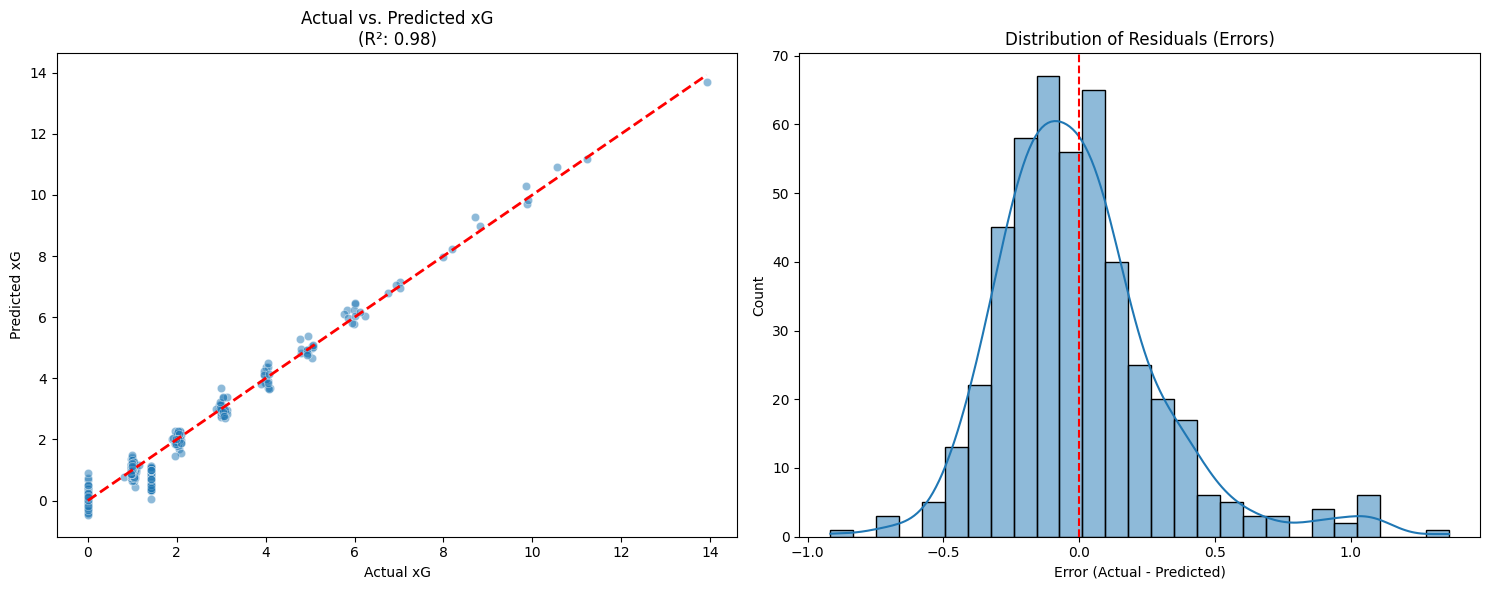

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax[0])
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_title(f'Actual vs. Predicted xG\n(R²: {r2:.2f})')
ax[0].set_xlabel('Actual xG')
ax[0].set_ylabel('Predicted xG')

# Plot 2: Residuals
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].axvline(0, color='r', linestyle='--')
ax[1].set_title('Distribution of Residuals (Errors)')
ax[1].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

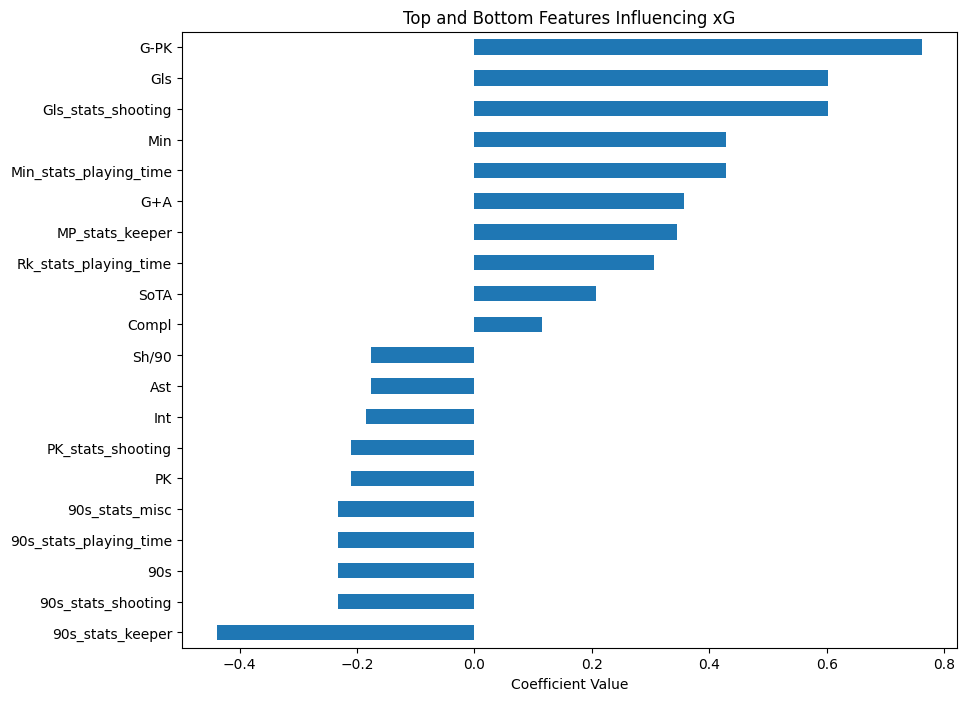

In [62]:
# Get coefficients from the linear model
importance = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

# Use concat instead of append
top_10 = importance.head(10)
bottom_10 = importance.tail(10)
to_plot = pd.concat([top_10, bottom_10])

# Plotting
plt.figure(figsize=(10, 8))
to_plot.plot(kind='barh')
plt.title('Top and Bottom Features Influencing xG')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis() # Optional: keeps the highest value at the top
plt.show()